## Import Library

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## Load Dataset

In [23]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving heart.csv to heart (1).csv
User uploaded file "heart (1).csv" with length 11328 bytes


In [24]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Data Understanding

In [25]:
print("Shape dataset:", df.shape)
print("\nDaftar kolom:")
print(df.columns.tolist())

df.info()

print(df.isnull().sum())

print("Jumlah data duplikat:", df.duplicated().sum())
df = df.drop_duplicates()

df.describe()

Shape dataset: (303, 14)

Daftar kolom:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
age         0
sex         0
cp          0
trestbps    0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Exploratory Data Analysis (EDA)

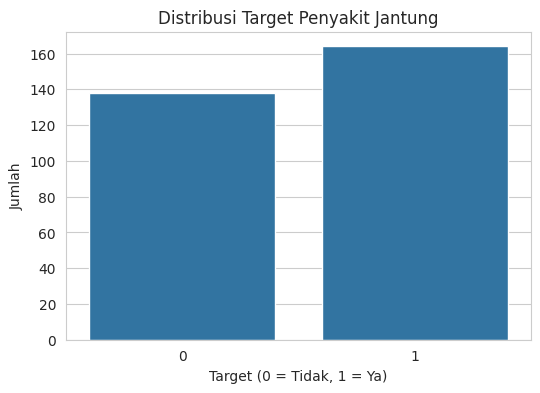

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target')
plt.title('Distribusi Target Penyakit Jantung')
plt.xlabel('Target (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.show()

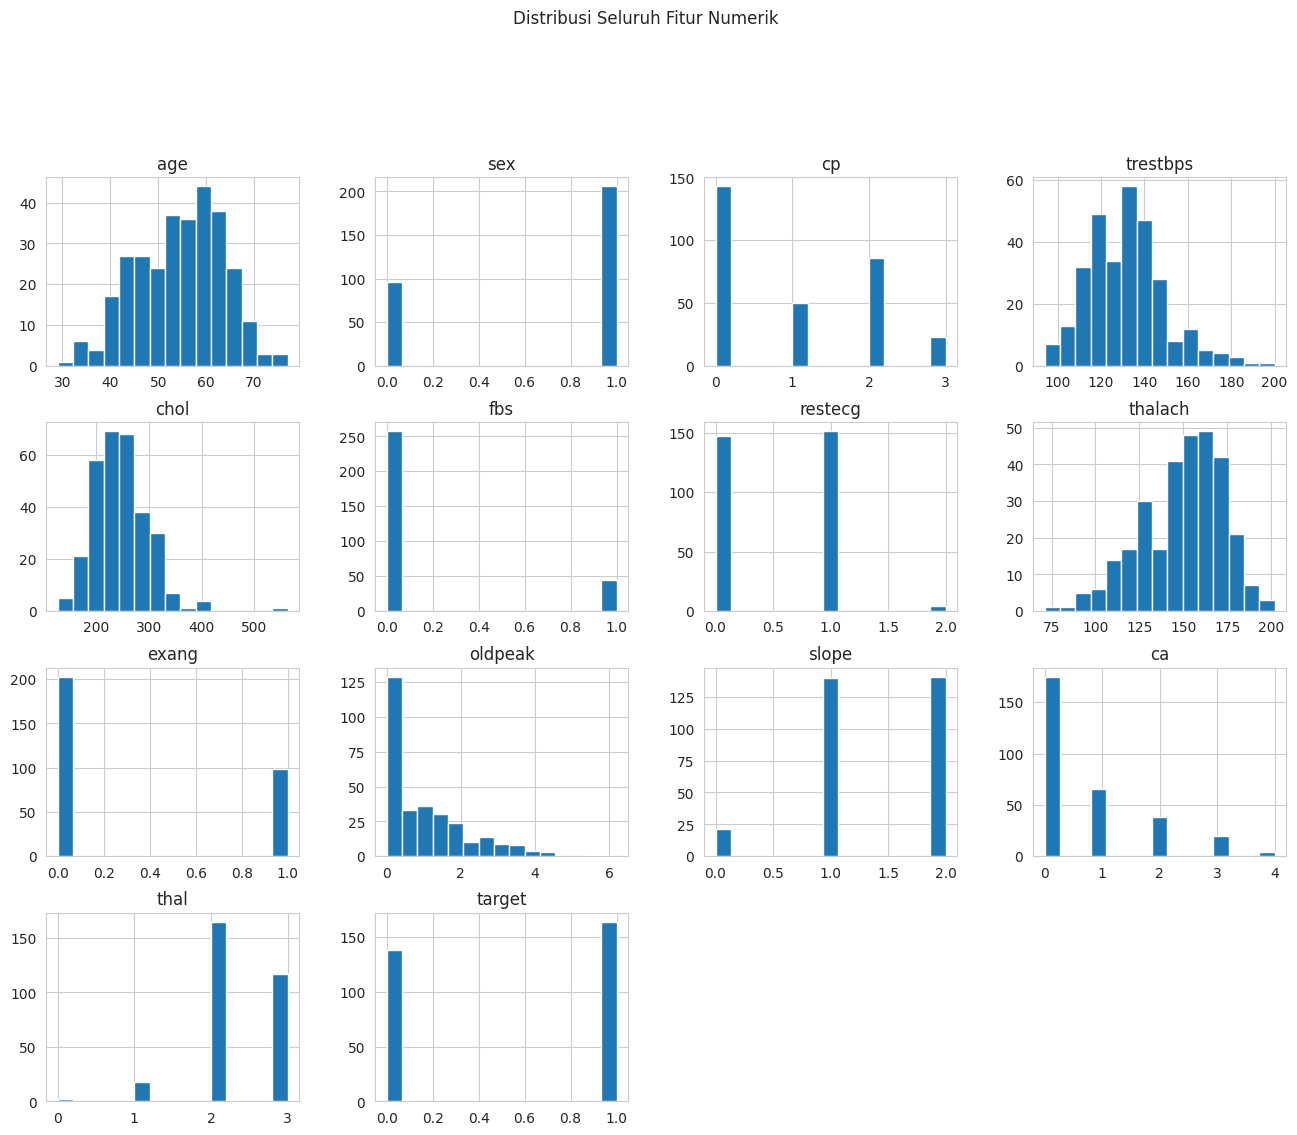

In [27]:
df.hist(figsize=(16,12), bins=15)
plt.suptitle('Distribusi Seluruh Fitur Numerik', y=1.02)
plt.show()

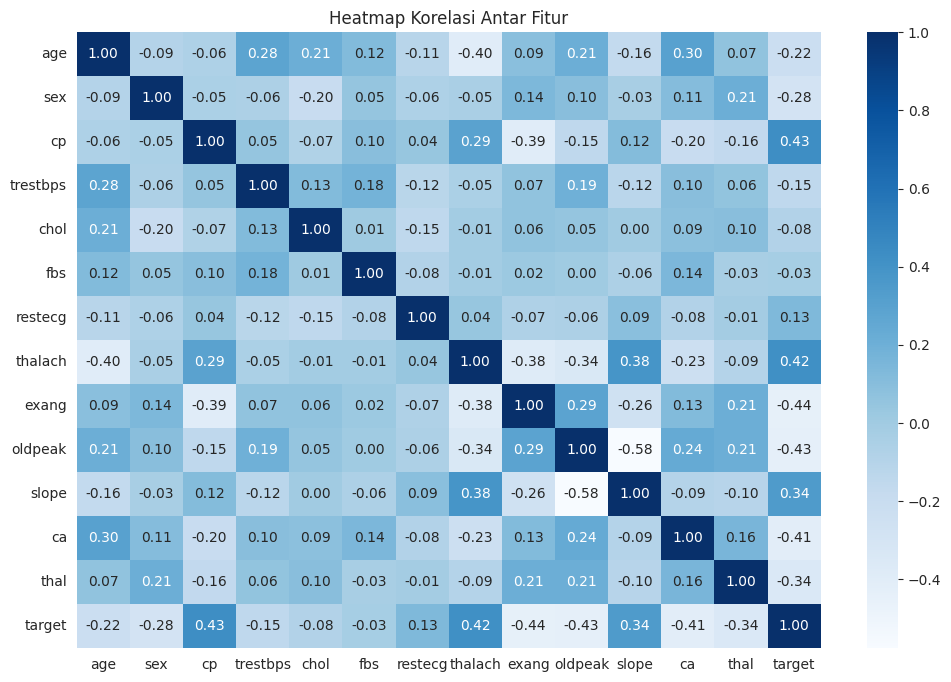

In [28]:
plt.figure(figsize=(12,8))
corr = df.drop(columns=['target_label'], errors='ignore').corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

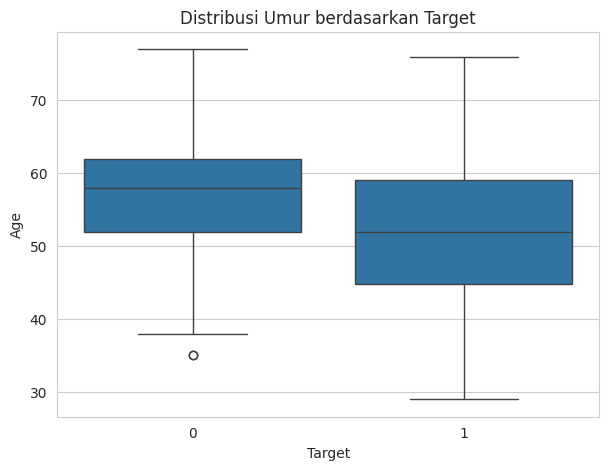

In [29]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='target', y='age')
plt.title('Distribusi Umur berdasarkan Target')
plt.xlabel('Target')
plt.ylabel('Age')
plt.show()

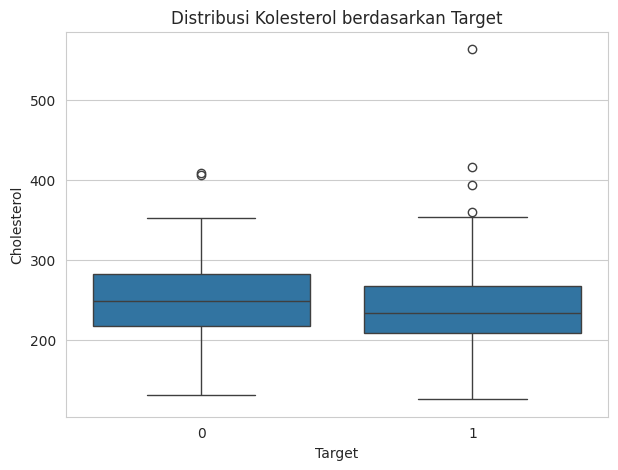

In [30]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='target', y='chol')
plt.title('Distribusi Kolesterol berdasarkan Target')
plt.xlabel('Target')
plt.ylabel('Cholesterol')
plt.show()

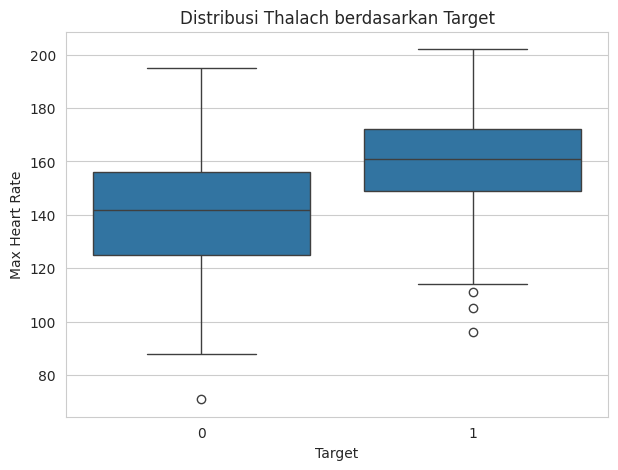

In [31]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='target', y='thalach')
plt.title('Distribusi Thalach berdasarkan Target')
plt.xlabel('Target')
plt.ylabel('Max Heart Rate')
plt.show()

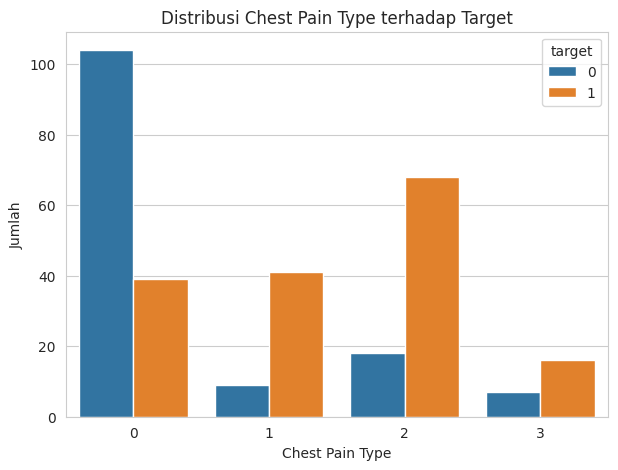

In [32]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='cp', hue='target')
plt.title('Distribusi Chest Pain Type terhadap Target')
plt.xlabel('Chest Pain Type')
plt.ylabel('Jumlah')
plt.show()

## Data Preparation

In [33]:
X = df.drop(columns=['target', 'target_label'], errors='ignore')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train: (241, 13)
X_test : (61, 13)
y_train: (241,)
y_test : (61,)


## Modeling

=== Decision Tree ===
Accuracy : 0.8032786885245902
Precision: 0.7441860465116279
Recall   : 0.9696969696969697
F1-score : 0.8421052631578947

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.61      0.74        28
           1       0.74      0.97      0.84        33

    accuracy                           0.80        61
   macro avg       0.84      0.79      0.79        61
weighted avg       0.84      0.80      0.79        61



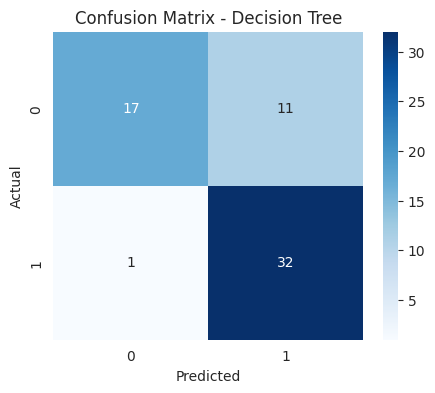

In [37]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("=== Decision Tree ===")
print("Accuracy :", acc_dt)
print("Precision:", prec_dt)
print("Recall   :", rec_dt)
print("F1-score :", f1_dt)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

=== KNN ===
Accuracy : 0.819672131147541
Precision: 0.7894736842105263
Recall   : 0.9090909090909091
F1-score : 0.8450704225352113

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



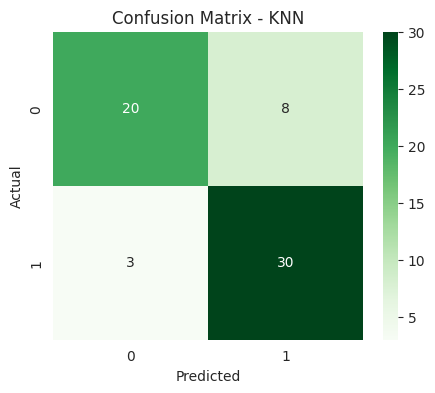

In [38]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("=== KNN ===")
print("Accuracy :", acc_knn)
print("Precision:", prec_knn)
print("Recall   :", rec_knn)
print("F1-score :", f1_knn)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Perbandingan Model

In [39]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'KNN'],
    'Accuracy': [acc_dt, acc_knn],
    'Precision': [prec_dt, prec_knn],
    'Recall': [rec_dt, rec_knn],
    'F1-Score': [f1_dt, f1_knn]
})

comparison = comparison.round(4)
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.8033,0.7442,0.9697,0.8421
1,KNN,0.8197,0.7895,0.9091,0.8451


In [40]:
best_model = comparison.loc[comparison['F1-Score'].idxmax(), 'Model']
print("Model terbaik berdasarkan F1-Score:", best_model)

Model terbaik berdasarkan F1-Score: KNN


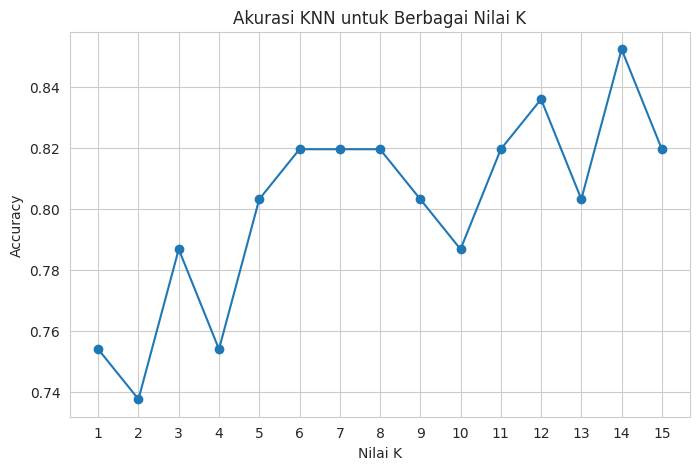

Nilai K terbaik: 14


In [41]:
k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.title('Akurasi KNN untuk Berbagai Nilai K')
plt.xlabel('Nilai K')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print("Nilai K terbaik:", best_k)